# Residual Income (EVA) Valuation - demo

Runs **fully offline** on synthetic clean-surplus financials (no API keys). Set `FMP_API_KEY` / `FRED_API_KEY` in a local `.env` for a real company.

Pipeline: historical residual income -> shared explicit forecast -> RI value vs simple DCF (DDM) -> exact gap decomposition -> terminal-growth sensitivity.

In [1]:
%pip install numpy>=1.26 pandas>=2.0 matplotlib>=3.8 pytest>=8.0 requests>=2.31 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\pilat\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
# ==== USER INPUTS ====
TICKER = "SYNTH"      # any real ticker if FMP_API_KEY is set
HORIZON = 10          # explicit forecast years
ROE_FADE_TO = 0.10    # ROE fades toward this (competition erodes excess returns)
PAYOUT = 0.40         # payout ratio in the forecast
G_TERM_RI = 0.0       # terminal RI growth (0 = flat excess returns)
G_TERM_DDM = 0.03     # terminal dividend growth for the DCF comparator
# =====================

In [3]:
import sys
sys.path.insert(0, "../src")
import numpy as np
from data_loader import load_financials
from residual_income import historical_residual_income, check_clean_surplus, build_forecast
from reconcile import reconcile, terminal_sensitivity

company = load_financials(TICKER)
s = company.statements
r = company.cost_of_equity
print(f"cost of equity = {r:.1%} | market cap = {company.market_cap:,.0f}")
print(f"clean-surplus max violation: {check_clean_surplus(s).abs().max():.2e}")
s.round(0)

cost of equity = 9.0% | market cap = 17,140
clean-surplus max violation: 0.00e+00


,net_income,dividends,book_equity
year,,,
2016,700.0,280.0,5420.0
2017,779.0,311.0,5887.0
2018,761.0,305.0,6344.0
2019,912.0,365.0,6891.0
2020,1055.0,422.0,7524.0
2021,927.0,371.0,8080.0
2022,937.0,375.0,8642.0
2023,1119.0,448.0,9314.0
2024,1220.0,488.0,10046.0


## 1. Historical residual income - is the firm earning above its cost of equity?

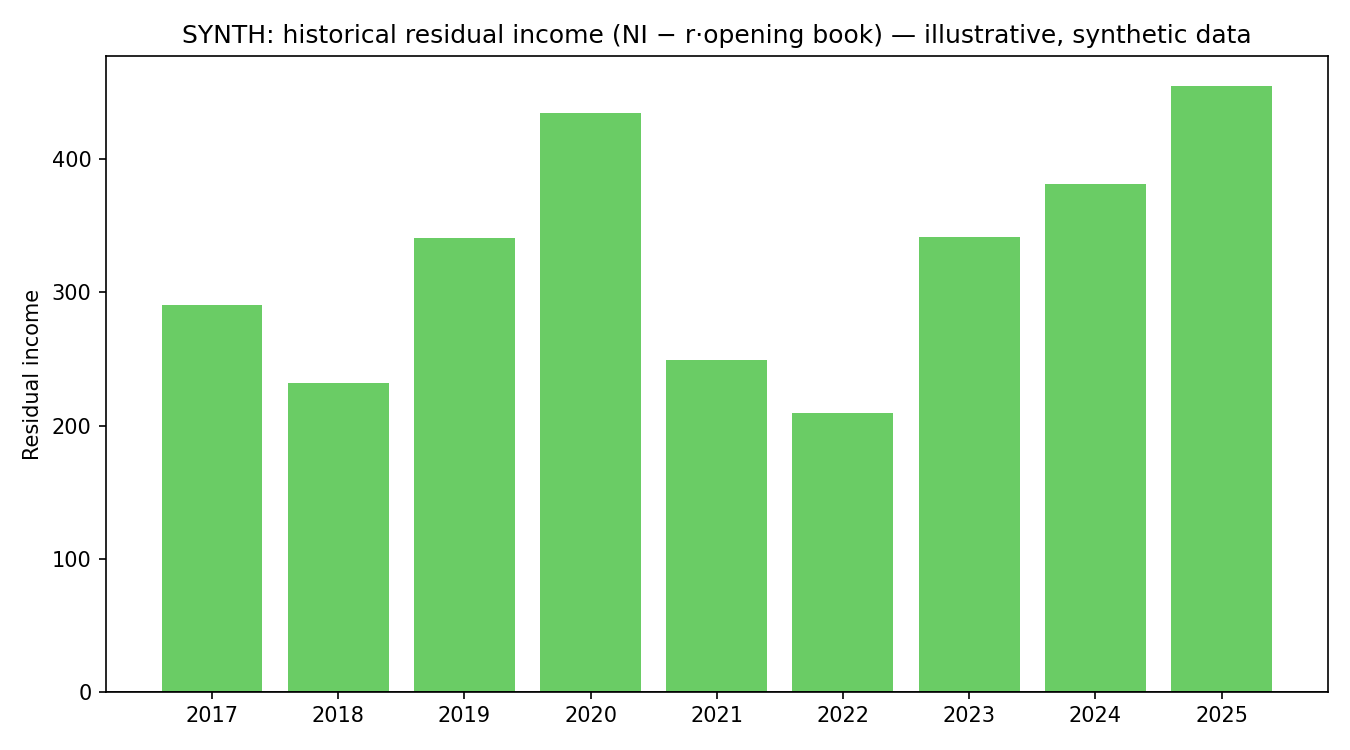

In [4]:
from plots import plot_ri_history
from IPython.display import Image, display
ri_hist = historical_residual_income(s, r)
display(Image(str(plot_ri_history(ri_hist, company.ticker))))

## 2. RI value vs simple DCF on the *same* forecast - and the exact gap decomposition

RI value:  14,452  (terminal share 7%)
DCF value: 10,306  (terminal share 57%)
Gap = 4,146; decomposition identity residual = 8.19e-12


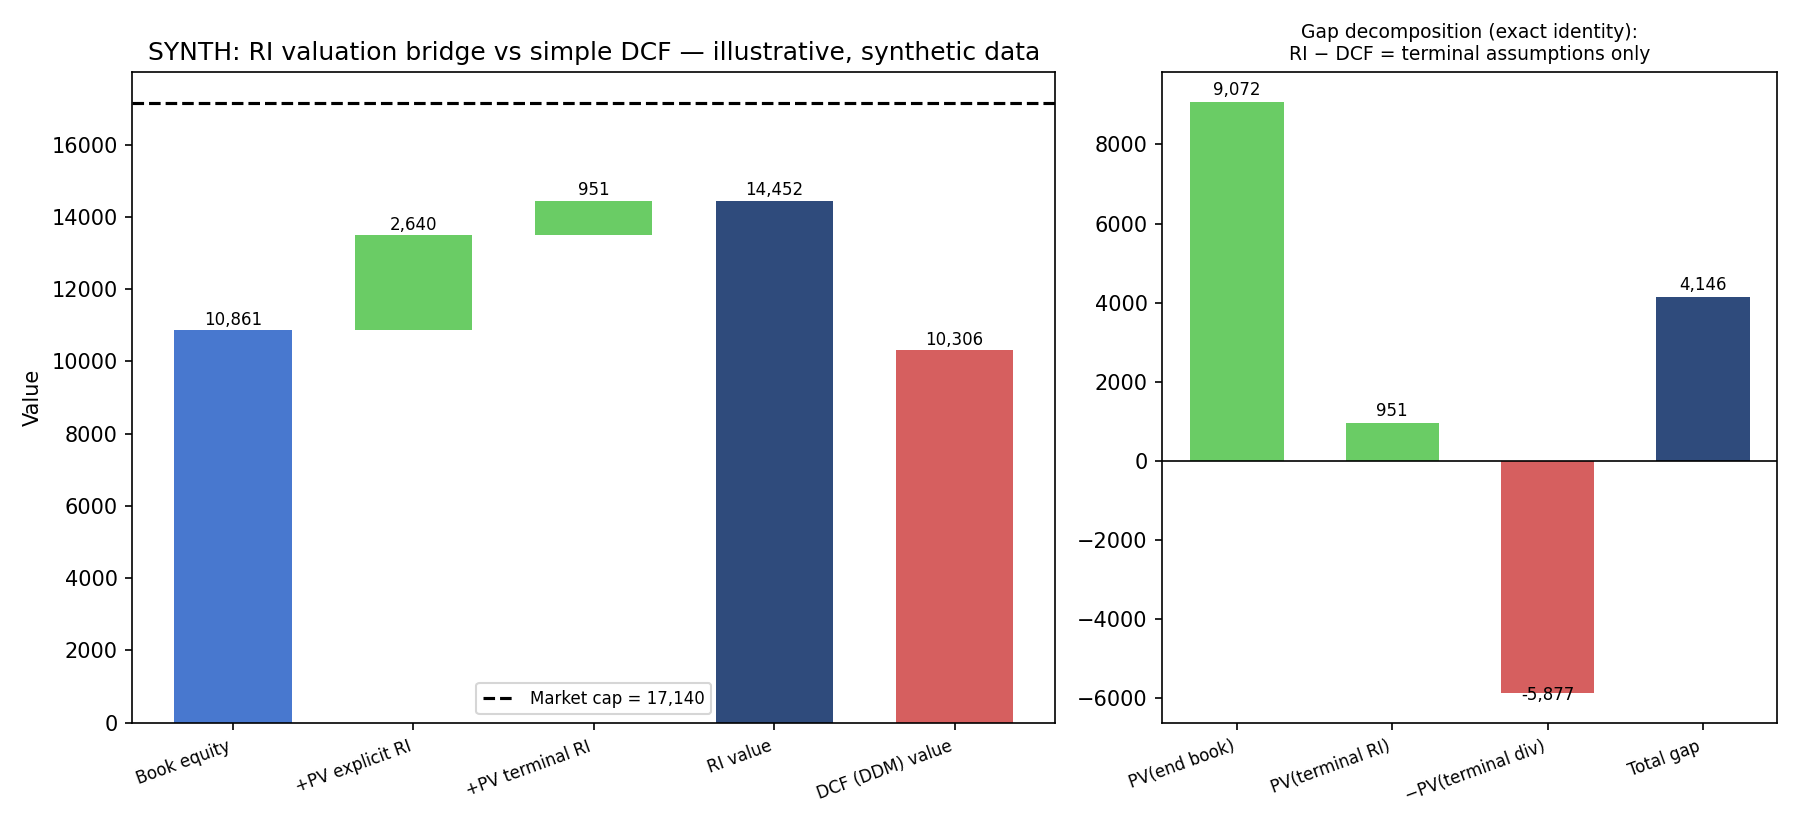

In [5]:
book0 = float(s["book_equity"].iloc[-1])
roe_now = float(s["net_income"].iloc[-1] / s["book_equity"].iloc[-2])
forecast = build_forecast(book0, roe_now, ROE_FADE_TO, PAYOUT, HORIZON)
recon = reconcile(book0, forecast, r, G_TERM_RI, G_TERM_DDM)
print(f"RI value:  {recon['ri_value']:,.0f}  (terminal share {recon['ri_terminal_share']:.0%})")
print(f"DCF value: {recon['ddm_value']:,.0f}  (terminal share {recon['ddm_terminal_share']:.0%})")
print(f"Gap = {recon['gap']:,.0f}; decomposition identity residual = {recon['gap_identity_residual']:.2e}")

from plots import plot_reconciliation_bridge
display(Image(str(plot_reconciliation_bridge(recon, company.market_cap, company.ticker))))

## 3. Terminal-growth sensitivity - why RI is the more defensible anchor

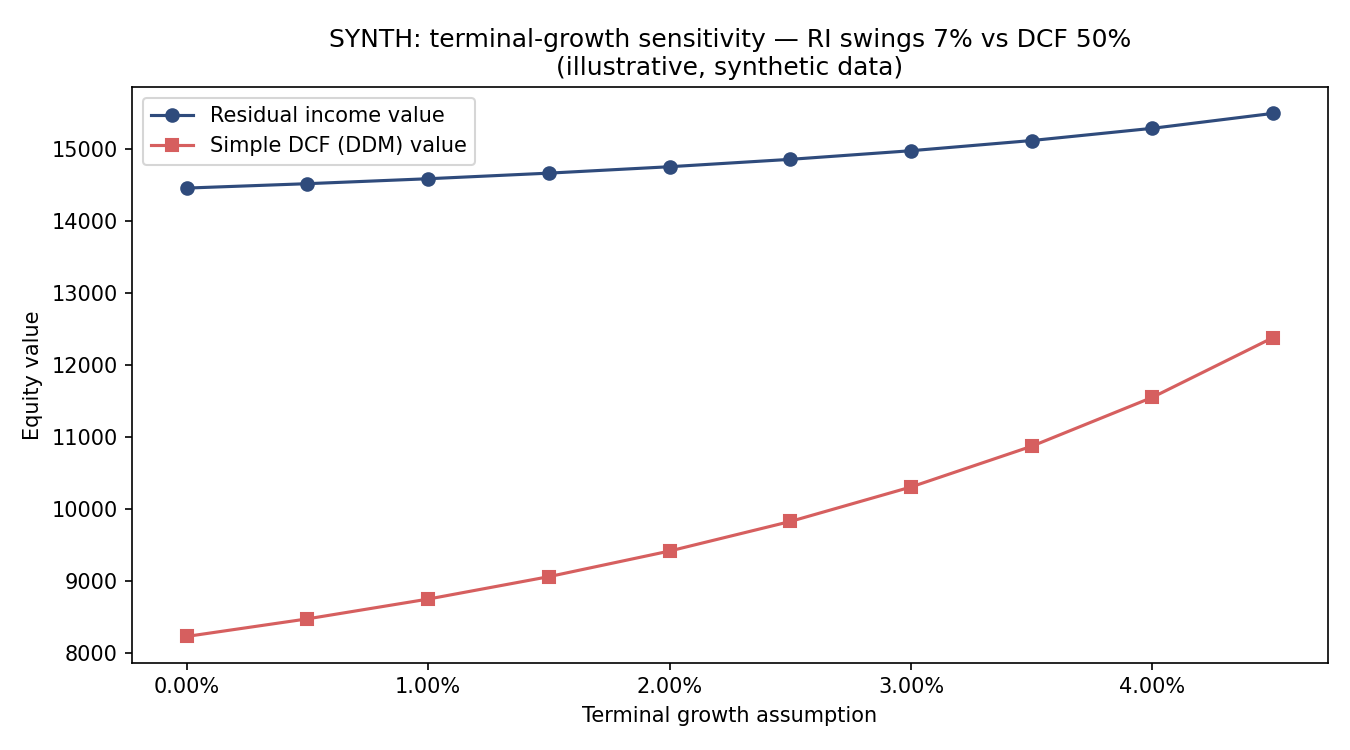

RI swing across g: 7% | DCF swing: 50%


In [6]:
g_grid = np.arange(0.0, 0.0451, 0.005)
g_grid = g_grid[g_grid < r - 0.005]
sens = terminal_sensitivity(book0, forecast, r, g_grid)

from plots import plot_terminal_sensitivity
display(Image(str(plot_terminal_sensitivity(sens, company.ticker))))
print(f"RI swing across g: {sens['ri'].max()/sens['ri'].min()-1:.0%} | DCF swing: {sens['ddm'].max()/sens['ddm'].min()-1:.0%}")